In [5]:
%pip install pandas
%pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


<Figure size 1200x600 with 0 Axes>

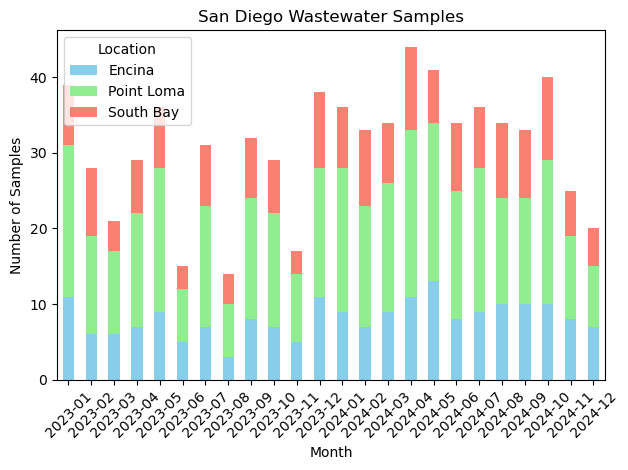

In [6]:
metadata = pd.read_csv('../data/all_covariants_metadata.tsv', sep='\t')
metadata['collection_date'] = pd.to_datetime(metadata['collection_date'])

# re-analysis of existing sample
metadata = metadata[~metadata['sample'].str.contains('rerun|separate|combined', case=False, na=False)]
metadata = metadata.drop_duplicates(subset=['sample'])

metadata['month'] = metadata['collection_date'].dt.to_period('M').astype(str)

location_monthly = metadata.groupby(['month', 'location']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 6))
location_monthly.plot(kind='bar', stacked=True, 
                     color=['skyblue', 'lightgreen', 'salmon'])

plt.title('San Diego Wastewater Samples')
plt.xlabel('Month')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45)
plt.legend(title='Location')
plt.tight_layout()
plt.savefig('search_data.pdf')
plt.show()
